In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import sqlite3
from pathlib import Path


df = pd.read_csv("../data/ai_company_adoption.csv")

WEEK 1

Visually checking the data

In [2]:
df


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149999,159996,COMP-10000,2025,Q4,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,19.01,1292,1027,1766,9.44,9.52,62,5.68,McKinsey Report,Phone Interview
150000,159997,COMP-10000,2026,Q1,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,15.56,466,883,803,10.65,6.94,56,5.57,Internal Corporate Survey,Research Compilation
150001,159998,COMP-10000,2026,Q2,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,13.38,1360,1474,1779,5.52,0.32,48,7.56,WEF Survey,API Scrape
150002,159999,COMP-10000,2026,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,12.75,1358,887,1648,11.87,7.85,69,6.00,WEF Survey,Research Compilation


Checking first 5 rows

In [3]:
df.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


Checking the last 5 rows

In [4]:
df.tail()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
149999,159996,COMP-10000,2025,Q4,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,19.01,1292,1027,1766,9.44,9.52,62,5.68,McKinsey Report,Phone Interview
150000,159997,COMP-10000,2026,Q1,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,15.56,466,883,803,10.65,6.94,56,5.57,Internal Corporate Survey,Research Compilation
150001,159998,COMP-10000,2026,Q2,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,13.38,1360,1474,1779,5.52,0.32,48,7.56,WEF Survey,API Scrape
150002,159999,COMP-10000,2026,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,12.75,1358,887,1648,11.87,7.85,69,6.00,WEF Survey,Research Compilation
150003,160000,COMP-10000,2026,Q4,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,14.42,1529,1501,2409,11.89,10.82,65,7.30,WEF Survey,API Scrape


Checking the shape

In [5]:
df.shape

(150004, 43)

Checking mathematical analysis on all the fields

In [6]:
df.describe()

,response_id,survey_year,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_projects_active,...,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction
count,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,...,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000,150004.000000
mean,79961.107310,2024.501000,2342.434975,1180.328326,2005.993700,18.507300,36.414775,4.931622,2.315138,6.270693,...,19.761757,6.267400,9.266981,111.371557,117.887790,181.647143,4.606528,4.814992,55.199848,5.420600
std,46160.045544,1.118007,4754.545321,2391.446171,9.473157,9.539317,14.544000,2.429304,0.946855,3.500149,...,9.222456,2.977463,5.637016,255.839360,261.663893,417.936375,5.318716,3.383086,8.593347,1.047147
min,1.000000,2023.000000,10.000000,1.010000,1990.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,40.000000,1.000000
25%,40019.750000,2024.000000,69.000000,33.880000,1998.000000,10.000000,26.430000,3.000000,2.000000,4.000000,...,13.360000,4.180000,5.070000,2.000000,3.000000,3.000000,0.780000,2.120000,49.000000,4.700000
50%,79937.500000,2025.000000,349.000000,184.160000,2006.000000,18.000000,36.320000,5.000000,2.000000,6.000000,...,19.700000,6.230000,9.060000,10.000000,12.000000,16.000000,4.480000,4.620000,55.000000,5.410000
75%,119914.250000,2026.000000,884.000000,444.150000,2014.000000,27.000000,46.200000,7.000000,3.000000,9.000000,...,26.020000,8.290000,13.120000,41.000000,41.000000,64.000000,8.240000,7.130000,61.000000,6.130000
max,160000.000000,2026.000000,19970.000000,9996.730000,2022.000000,36.000000,100.000000,10.000000,6.000000,20.000000,...,59.630000,19.150000,34.360000,2417.000000,1980.000000,3881.000000,30.000000,20.790000,97.000000,9.760000


WEEK 2

Checking fields with null values

In [7]:
df.isnull().sum()

response_id                    0
company_id                     0
survey_year                    0
quarter                        0
country                        0
region                         1
industry                       0
company_size                   1
num_employees                  0
annual_revenue_usd_millions    0
company_founding_year          0
company_age                    0
company_age_group              0
ai_adoption_rate               0
ai_adoption_stage              1
years_using_ai                 0
ai_primary_tool                0
num_ai_tools_used              0
ai_use_case                    0
ai_projects_active             0
ai_training_hours              0
ai_budget_percentage           0
ai_maturity_score              0
ai_failure_rate                0
ai_investment_per_employee     0
regulatory_compliance_score    0
data_privacy_level             0
ai_ethics_committee            0
ai_risk_management_score       0
remote_work_percentage         0
employee_s

Let us identify records with null values

In [8]:
df[df["survey_source"].isnull() | df["ai_adoption_stage"].isnull() | df["region"].isnull() | df["company_size"].isnull() ]

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
14,14,COMP-00001,2026,Q2,Italy,NaN,Education,NaN,57,48.31,...,11.81,2,3,4,4.31,9.75,52,5.22,LinkedIn Poll,Research Compilation
22,21,COMP-00002,2024,Q1,UK,Europe,Finance,Startup,18,14.66,...,7.84,0,1,2,5.43,6.11,55,3.65,NaN,Phone Interview
149983,159980,COMP-09999,2025,Q4,Poland,Europe,Finance,Startup,16,4.56,...,3.93,1,0,0,9.06,7.96,46,3.87,McKinsey Report,Phone Interview


There are only 3 rows with null values so we can safely drop those rows

In [9]:
df.dropna(subset=["survey_source"],inplace=True) 
df.dropna(subset=["ai_adoption_stage"],inplace=True) 
df.dropna(subset=["region"],inplace=True) 
df.dropna(subset=["company_size"],inplace=True) 

Let us check records with null values again

In [10]:
df.isnull().sum()

response_id                    0
company_id                     0
survey_year                    0
quarter                        0
country                        0
region                         0
industry                       0
company_size                   0
num_employees                  0
annual_revenue_usd_millions    0
company_founding_year          0
company_age                    0
company_age_group              0
ai_adoption_rate               0
ai_adoption_stage              0
years_using_ai                 0
ai_primary_tool                0
num_ai_tools_used              0
ai_use_case                    0
ai_projects_active             0
ai_training_hours              0
ai_budget_percentage           0
ai_maturity_score              0
ai_failure_rate                0
ai_investment_per_employee     0
regulatory_compliance_score    0
data_privacy_level             0
ai_ethics_committee            0
ai_risk_management_score       0
remote_work_percentage         0
employee_s

Let us check the shape again

In [11]:
df.shape

(150001, 43)

Checking duplicate records

In [12]:
print(df.loc[df.duplicated(keep=False)])

        response_id  company_id  survey_year quarter  country  region  \
149997       159995  COMP-10000         2025      Q3  Nigeria  Africa   
149998       159995  COMP-10000         2025      Q3  Nigeria  Africa   

          industry company_size  num_employees  annual_revenue_usd_millions  \
149997  Healthcare   Enterprise          18038                      2040.01   
149998  Healthcare   Enterprise          18038                      2040.01   

        ...  productivity_change_percent  jobs_displaced jobs_created  \
149997  ...                        11.31             700         1260   
149998  ...                        11.31             700         1260   

        reskilled_employees revenue_growth_percent  cost_reduction_percent  \
149997                 1387                   5.95                    7.89   
149998                 1387                   5.95                    7.89   

       innovation_score  customer_satisfaction survey_source  \
149997               57

There are 2 rows with duplicate values which we can safely delete   

In [13]:
df.drop_duplicates(keep="first", inplace=True)

Let us check the shape again

In [14]:
df.shape

(150000, 43)

Checking unique values in the field survey_year

In [15]:
df["survey_year"].unique()

array([2023, 2024, 2025, 2026])

Checking unique values in the field company_id, the data seem to be pretty good

In [16]:
df["company_id"].unique()

<StringArray>
['COMP-00001', 'COMP-00002', 'COMP-00003', 'COMP-00004', 'COMP-00005',
 'COMP-00006', 'COMP-00007', 'COMP-00008', 'COMP-00009', 'COMP-00010',
 ...
 'COMP-09991', 'COMP-09992', 'COMP-09993', 'COMP-09994', 'COMP-09995',
 'COMP-09996', 'COMP-09997', 'COMP-09998', 'COMP-09999', 'COMP-10000']
Length: 10000, dtype: str

Checking unique values in the field country , the data seem to be pretty good

In [17]:
df["country"].unique()

<StringArray>
[       'Italy',           'UK',      'Germany',          'USA',
        'Chile',  'Philippines', 'South Africa',        'India',
     'Thailand',     'Malaysia',       'Sweden',        'Spain',
        'Egypt',  'Netherlands',     'Colombia',       'Canada',
    'Australia',    'Indonesia',    'Singapore',        'China',
      'Vietnam',      'Nigeria',        'Japan',       'Brazil',
  'New Zealand',       'Poland',    'Argentina',  'South Korea',
       'France',        'Kenya']
Length: 30, dtype: str

Checking duplicate values

Checking number of records by country

In [18]:
df["country"].value_counts()

country
France          5637
Japan           5629
South Korea     5443
Germany         5327
Chile           5190
Egypt           5125
Netherlands     5118
Philippines     5091
Poland          5086
USA             5058
New Zealand     5058
UK              5027
South Africa    5003
Italy           4963
Australia       4944
India           4941
Colombia        4918
Indonesia       4915
Brazil          4907
Argentina       4894
Sweden          4881
Kenya           4871
Singapore       4854
Spain           4796
Nigeria         4788
Thailand        4782
Malaysia        4718
Canada          4682
China           4677
Vietnam         4677
Name: count, dtype: int64

Checking duplicate records, seem to be there are no duplicates

In [19]:
df.loc[df.duplicated(keep=False)]

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method


Checking field types

In [20]:
df.dtypes

response_id                      int64
company_id                         str
survey_year                      int64
quarter                            str
country                            str
region                             str
industry                           str
company_size                       str
num_employees                    int64
annual_revenue_usd_millions    float64
company_founding_year            int64
company_age                      int64
company_age_group                  str
ai_adoption_rate               float64
ai_adoption_stage                  str
years_using_ai                   int64
ai_primary_tool                    str
num_ai_tools_used                int64
ai_use_case                        str
ai_projects_active               int64
ai_training_hours              float64
ai_budget_percentage           float64
ai_maturity_score              float64
ai_failure_rate                float64
ai_investment_per_employee     float64
regulatory_compliance_sco

Analysing data visually

In [21]:
df.describe()

,response_id,survey_year,num_employees,annual_revenue_usd_millions,company_founding_year,company_age,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_projects_active,...,task_automation_rate,time_saved_per_week,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,...,150000.000000,150000.000000,150000.000000,150000.00000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,79961.106207,2024.500987,2342.376580,1180.345751,2005.993767,18.507220,36.414726,4.931580,2.315120,6.270693,...,19.761744,6.267406,9.266996,111.36984,117.882507,181.642700,4.606486,4.814909,55.199920,5.420619
std,46158.813039,1.118013,4754.424755,2391.471420,9.473220,9.539367,14.544096,2.429316,0.946826,3.500142,...,9.222562,2.977495,5.637067,255.83778,261.650245,417.929587,5.318773,3.383086,8.593423,1.047142
min,1.000000,2023.000000,10.000000,1.010000,1990.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,-5.000000,0.000000,40.000000,1.000000
25%,40020.750000,2024.000000,69.000000,33.880000,1998.000000,10.000000,26.430000,3.000000,2.000000,4.000000,...,13.360000,4.180000,5.070000,2.00000,3.000000,3.000000,0.780000,2.120000,49.000000,4.700000
50%,79937.500000,2025.000000,349.000000,184.160000,2006.000000,18.000000,36.320000,5.000000,2.000000,6.000000,...,19.700000,6.230000,9.060000,10.00000,12.000000,16.000000,4.480000,4.620000,55.000000,5.410000
75%,119913.250000,2026.000000,884.000000,444.150000,2014.000000,27.000000,46.200000,7.000000,3.000000,9.000000,...,26.020000,8.290000,13.120000,41.00000,41.000000,64.000000,8.240000,7.130000,61.000000,6.130000
max,160000.000000,2026.000000,19970.000000,9996.730000,2022.000000,36.000000,100.000000,10.000000,6.000000,20.000000,...,59.630000,19.150000,34.360000,2417.00000,1980.000000,3881.000000,30.000000,20.790000,97.000000,9.760000


A simple visual check is "years_using_ai" mean is 4.931580 (years) which is little shorter than 50% i.e. 5 (years), that means it is slightly negatively skewed. 
Trying histogram on that field.

<Axes: >

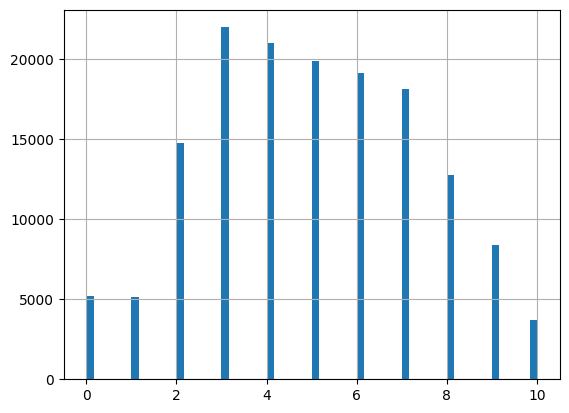

In [22]:
df['years_using_ai'].hist(bins=60)


And, the reason is obvious that use of AI in the various industries across various countries has started since last 5 years or so. Trying boxplot on that field. Should be done on all quantitative fields.

<Axes: xlabel='years_using_ai'>

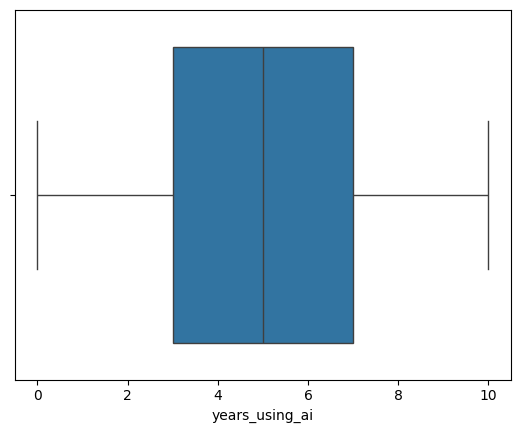

In [23]:
sns.boxplot(x=df['years_using_ai']) 


In [24]:
df.dtypes

response_id                      int64
company_id                         str
survey_year                      int64
quarter                            str
country                            str
region                             str
industry                           str
company_size                       str
num_employees                    int64
annual_revenue_usd_millions    float64
company_founding_year            int64
company_age                      int64
company_age_group                  str
ai_adoption_rate               float64
ai_adoption_stage                  str
years_using_ai                   int64
ai_primary_tool                    str
num_ai_tools_used                int64
ai_use_case                        str
ai_projects_active               int64
ai_training_hours              float64
ai_budget_percentage           float64
ai_maturity_score              float64
ai_failure_rate                float64
ai_investment_per_employee     float64
regulatory_compliance_sco

Multivary analysis - to find the relationship between two or more variables

In [25]:
df_corr=df[[
    'ai_adoption_rate',
    'ai_budget_percentage',
    'ai_failure_rate',
    'ai_investment_per_employee',
    'ai_maturity_score',
    'ai_training_hours',
    'annual_revenue_usd_millions',
    'cost_reduction_percent',
    'customer_satisfaction',
    'employee_satisfaction_score',
    'productivity_change_percent',
    'remote_work_percentage',
    'revenue_growth_percent',
    'task_automation_rate',
    'time_saved_per_week',
    'ai_projects_active',
    'ai_risk_management_score',
    'company_age',
    'company_founding_year',
    'innovation_score',
    'jobs_created',
    'jobs_displaced',
    'num_ai_tools_used',
    'num_employees',
    'regulatory_compliance_score',
    'reskilled_employees',
    'response_id',
    'survey_year',
    'years_using_ai',
]].corr()
df_corr

,ai_adoption_rate,ai_budget_percentage,ai_failure_rate,ai_investment_per_employee,ai_maturity_score,ai_training_hours,annual_revenue_usd_millions,cost_reduction_percent,customer_satisfaction,employee_satisfaction_score,...,innovation_score,jobs_created,jobs_displaced,num_ai_tools_used,num_employees,regulatory_compliance_score,reskilled_employees,response_id,survey_year,years_using_ai
ai_adoption_rate,1.000000,0.744476,-0.657283,0.264802,0.841339,0.728420,0.191219,0.404302,0.422141,0.329869,...,0.509864,0.305982,0.278499,0.539365,0.179024,0.014001,0.268673,0.009930,0.146956,0.194012
ai_budget_percentage,0.744476,1.000000,-0.527048,0.350236,0.819248,0.560236,0.279771,0.328713,0.368443,0.307426,...,0.445472,0.356931,0.327195,0.400556,0.271892,0.010780,0.321456,0.004748,0.096832,0.138527
ai_failure_rate,-0.657283,-0.527048,1.000000,-0.194754,-0.697749,-0.739570,-0.188723,-0.288156,-0.434765,-0.335864,...,-0.385851,-0.259982,-0.237706,-0.351571,-0.179474,-0.003887,-0.272529,-0.004394,-0.096460,-0.098316
ai_investment_per_employee,0.264802,0.350236,-0.194754,1.000000,0.297108,0.204215,0.277906,0.117579,0.132962,0.110891,...,0.161687,-0.024051,-0.027974,0.143924,-0.056369,0.001123,-0.029166,-0.013686,0.030167,0.043809
ai_maturity_score,0.841339,0.819248,-0.697749,0.297108,1.000000,0.821696,0.309269,0.386162,0.458789,0.380672,...,0.531790,0.398065,0.364793,0.454016,0.298857,0.010925,0.388040,0.006996,0.115645,0.155064
ai_training_hours,0.728420,0.560236,-0.739570,0.204215,0.821696,1.000000,0.221786,0.328314,0.415638,0.335348,...,0.444496,0.301574,0.275714,0.393811,0.212653,0.008030,0.344071,0.007489,0.104681,0.134539
annual_revenue_usd_millions,0.191219,0.279771,-0.188723,0.277906,0.309269,0.221786,1.000000,0.102084,0.130582,0.116776,...,0.151722,0.702370,0.673367,0.102231,0.748031,-0.001345,0.677357,0.000858,0.000583,0.020463
cost_reduction_percent,0.404302,0.328713,-0.288156,0.117579,0.386162,0.328314,0.102084,1.000000,0.205888,0.147959,...,0.222638,0.149631,0.173077,0.218866,0.097283,0.006638,0.135670,0.004617,0.060256,0.072870
customer_satisfaction,0.422141,0.368443,-0.434765,0.132962,0.458789,0.415638,0.130582,0.205888,1.000000,0.190328,...,0.248808,0.177026,0.172427,0.226932,0.124257,0.007297,0.174794,0.002344,0.061066,0.068908
employee_satisfaction_score,0.329869,0.307426,-0.335864,0.110891,0.380672,0.335348,0.116776,0.147959,0.190328,1.000000,...,0.203174,0.152704,0.139810,0.175625,0.112979,0.001268,0.151154,0.000629,0.048072,0.060904


Converting the result to csv for easier analysis of the result

In [26]:
df_corr.to_csv('../other files/df_corr.csv')

Let us create heatmap

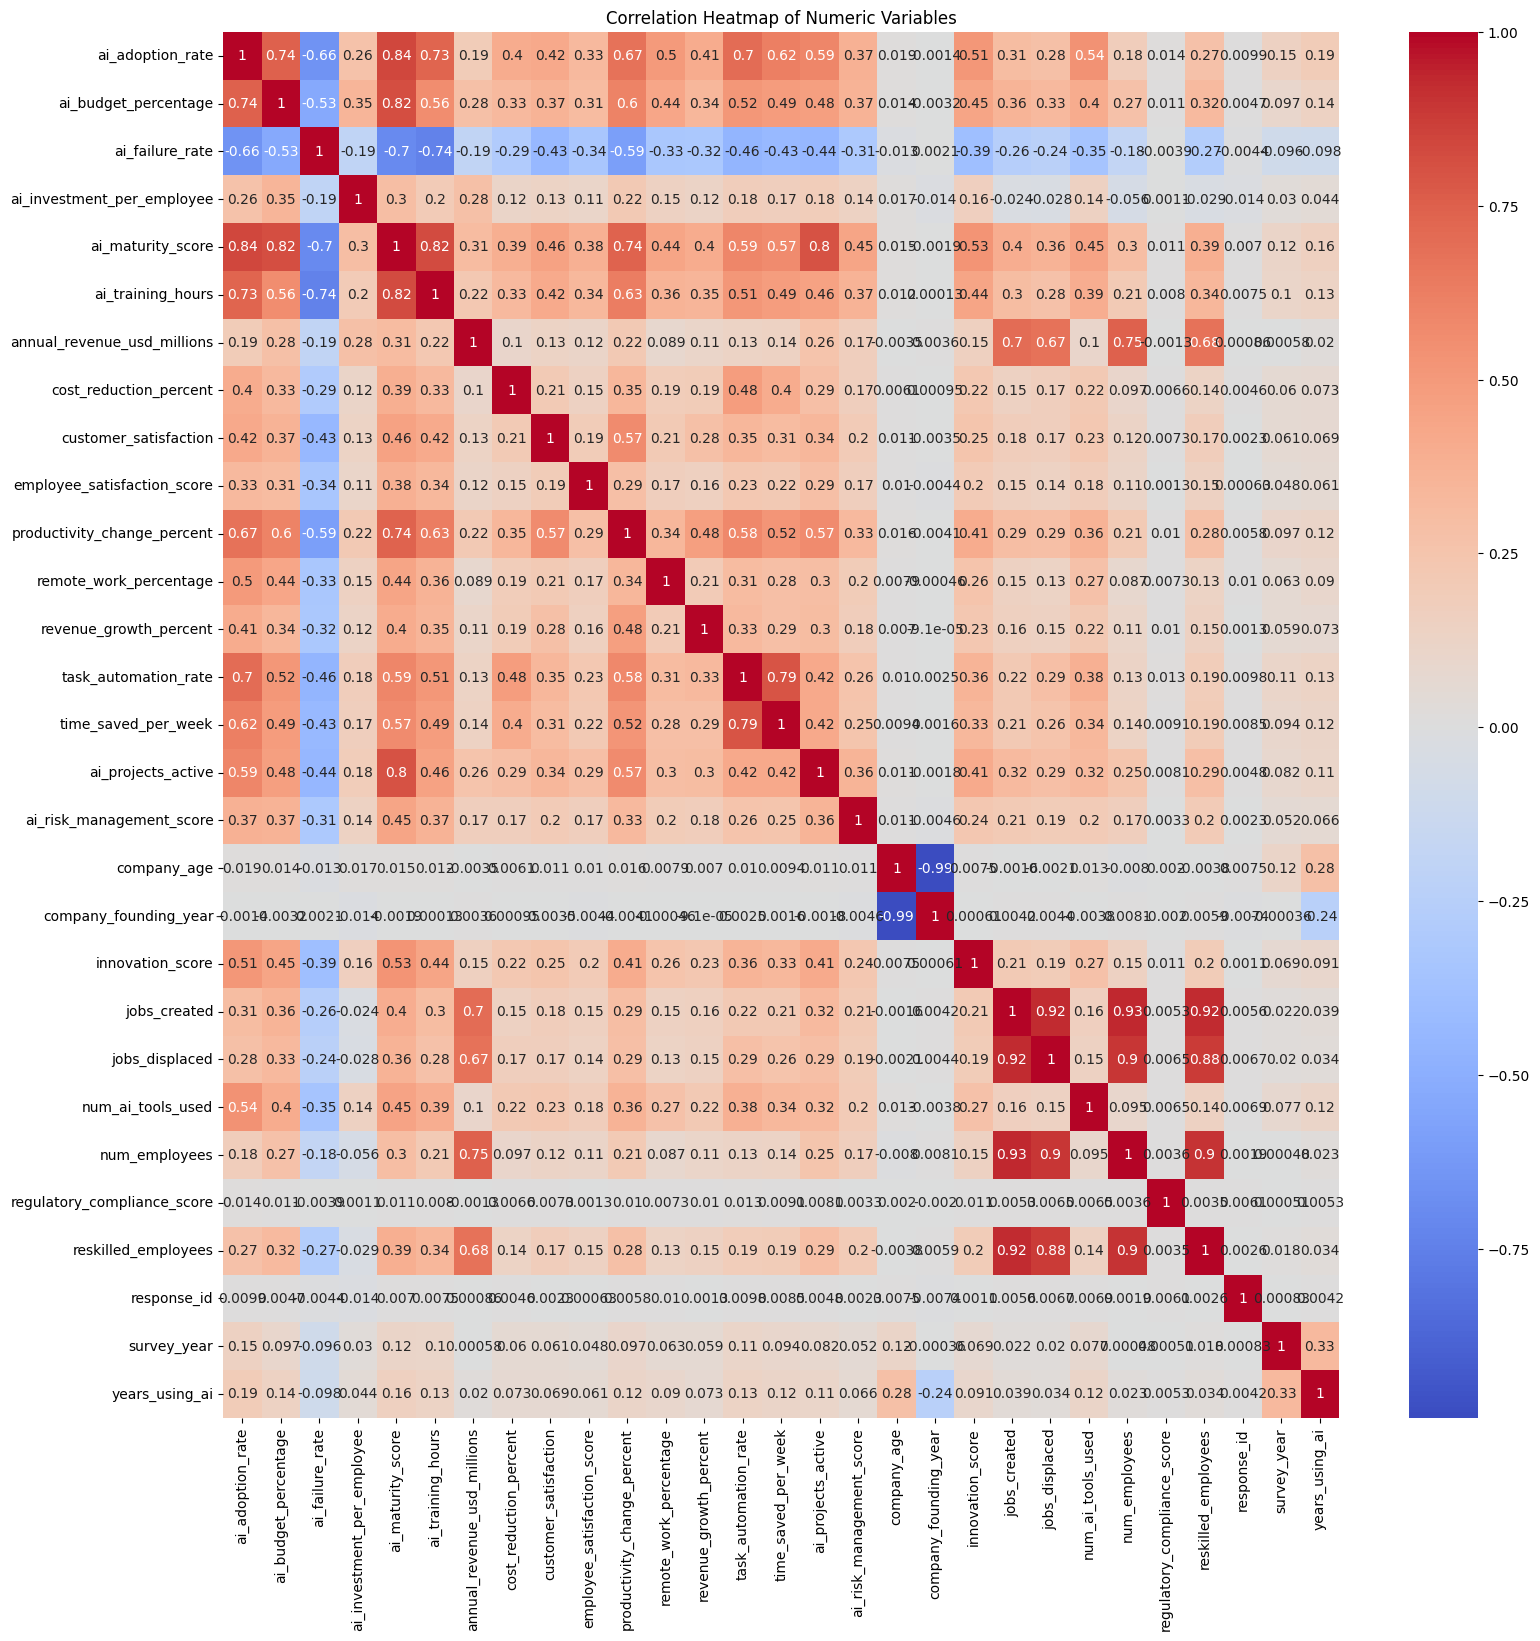

In [27]:
fig, ax = plt.subplots(figsize=(18,18))
# sns.heatmap(df_corr, annot=True, cmap='mako')
sns.heatmap(df_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

Let us try to plot some values on pairplot

In [28]:
df[[
   'ai_adoption_stage',
   'ai_ethics_committee',
   'ai_primary_tool',
   'ai_use_case',
   'company_age_group',
   'company_id',
   'company_size',
   'country',
   'data_collection_method',
   'data_privacy_level',
   'industry',
   'quarter',
   'region',
   ]]

,ai_adoption_stage,ai_ethics_committee,ai_primary_tool,ai_use_case,company_age_group,company_id,company_size,country,data_collection_method,data_privacy_level,industry,quarter,region
0,pilot,No,ChatGPT,Customer Support,16-30 years,COMP-00001,Startup,Italy,API Scrape,Medium,Education,Q1,Europe
1,pilot,No,ChatGPT,Software Development,16-30 years,COMP-00001,Startup,Italy,Phone Interview,High,Education,Q2,Europe
2,pilot,No,Custom Internal AI,HR Automation,16-30 years,COMP-00001,Startup,Italy,Research Compilation,High,Education,Q3,Europe
3,pilot,No,Custom Internal AI,Software Development,16-30 years,COMP-00001,Startup,Italy,Research Compilation,High,Education,Q4,Europe
4,pilot,Yes,ChatGPT,Customer Support,16-30 years,COMP-00001,Startup,Italy,Research Compilation,High,Education,Q1,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149999,partial,Yes,ChatGPT,HR Automation,6-15 years,COMP-10000,Enterprise,Nigeria,Phone Interview,High,Healthcare,Q4,Africa
150000,partial,No,ChatGPT,Predictive Maintenance,16-30 years,COMP-10000,Enterprise,Nigeria,Research Compilation,Medium,Healthcare,Q1,Africa
150001,partial,Yes,Claude,Customer Support,16-30 years,COMP-10000,Enterprise,Nigeria,API Scrape,Low,Healthcare,Q2,Africa
150002,partial,Yes,ChatGPT,Medical Diagnostics,16-30 years,COMP-10000,Enterprise,Nigeria,Research Compilation,Medium,Healthcare,Q3,Africa


I would like to see which country has most number of companies working on AI - France is top on the list!!

In [29]:
df.groupby(['country','region']).size().sort_values(ascending=False)

country       region       
France        Europe           5637
Japan         Asia             5629
South Korea   Asia             5443
Germany       Europe           5327
Chile         South America    5190
Egypt         Africa           5125
Netherlands   Europe           5118
Philippines   Asia             5091
Poland        Europe           5086
USA           North America    5058
New Zealand   Oceania          5058
UK            Europe           5027
South Africa  Africa           5003
Italy         Europe           4963
Australia     Oceania          4944
India         Asia             4941
Colombia      South America    4918
Indonesia     Asia             4915
Brazil        South America    4907
Argentina     South America    4894
Sweden        Europe           4881
Kenya         Africa           4871
Singapore     Asia             4854
Spain         Europe           4796
Nigeria       Africa           4788
Thailand      Asia             4782
Malaysia      Asia             4718


I would like to see which region has most number of companies working on AI - Asis is top on the list!!

In [30]:
df.groupby(['region']).size().sort_values(ascending=False)

region
Asia             49727
Europe           40835
South America    19909
Africa           19787
Oceania          10002
North America     9740
dtype: int64

Checking rows from Oceania

In [31]:
df[df['region']=='Oceania']

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
412,449,COMP-00029,2023,Q1,Australia,Oceania,Finance,Enterprise,16338,1707.07,...,9.65,291,605,1618,9.92,0.41,69,5.10,LinkedIn Poll,Research Compilation
413,450,COMP-00029,2023,Q2,Australia,Oceania,Finance,Enterprise,16338,1707.07,...,13.14,449,951,496,2.89,6.18,58,6.63,LinkedIn Poll,Online Survey
414,451,COMP-00029,2023,Q3,Australia,Oceania,Finance,Enterprise,16338,1707.07,...,4.97,496,589,1512,4.09,3.73,56,4.11,LinkedIn Poll,Phone Interview
415,452,COMP-00029,2023,Q4,Australia,Oceania,Finance,Enterprise,16338,1707.07,...,4.07,430,725,778,-3.93,6.59,69,5.29,McKinsey Report,Online Survey
416,453,COMP-00029,2024,Q1,Australia,Oceania,Finance,Enterprise,16338,1707.07,...,20.01,1216,917,2407,-0.05,8.99,66,7.28,WEF Survey,Phone Interview
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149921,159916,COMP-09995,2025,Q4,New Zealand,Oceania,Consulting,SME,629,370.86,...,3.20,27,34,59,3.86,8.99,49,3.79,Internal Corporate Survey,Online Survey
149922,159917,COMP-09995,2026,Q1,New Zealand,Oceania,Consulting,SME,629,370.86,...,8.07,26,29,45,9.00,3.17,67,5.22,McKinsey Report,Phone Interview
149923,159918,COMP-09995,2026,Q2,New Zealand,Oceania,Consulting,SME,629,370.86,...,16.20,42,25,24,13.59,0.56,46,5.76,McKinsey Report,API Scrape
149924,159919,COMP-09995,2026,Q3,New Zealand,Oceania,Consulting,SME,629,370.86,...,8.88,35,20,47,-1.60,1.19,47,4.78,WEF Survey,Phone Interview


Checking AI is used in which industry - Technology and Finance!

In [32]:
df.groupby(['industry']).size().sort_values(ascending=False)

industry
Technology       21107
Finance          20166
Healthcare       18642
Manufacturing    17501
Retail           16377
Agriculture      15570
Education        15172
Logistics        12961
Consulting       12504
dtype: int64

Let us see total revenu of the companies by countr and Japan is on the top!! USA is not even in the top 10!!!

In [33]:
df.groupby('country')['annual_revenue_usd_millions'].sum().sort_values(ascending=False)


country
France          7330830.32
Japan           6942763.64
Philippines     6879627.59
Egypt           6672076.32
Poland          6566811.58
Spain           6533491.72
Italy           6491352.28
India           6321352.10
South Africa    6299339.90
Australia       6264244.13
Nigeria         6250373.07
South Korea     6209407.18
Sweden          6147737.87
New Zealand     5993888.53
Vietnam         5959189.28
Brazil          5815825.37
Germany         5780539.31
Thailand        5767963.52
USA             5738107.77
UK              5702204.35
Malaysia        5619263.96
Netherlands     5532909.20
Chile           5329653.61
Singapore       5276613.79
Indonesia       5190104.03
Canada          5142208.26
Kenya           4912485.13
China           4887981.04
Colombia        4767314.13
Argentina       4726203.68
Name: annual_revenue_usd_millions, dtype: float64

Let us find out contry wise Annual Revenues those are involved in AI technologieas

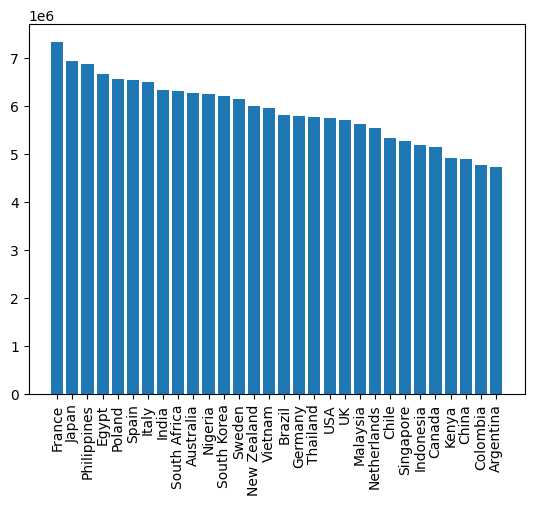

In [34]:
ann_rev = df.groupby('country')['annual_revenue_usd_millions'].sum().sort_values(ascending=False)
plt.bar(ann_rev.index, ann_rev.values)
plt.xticks(rotation=90)
plt.show()



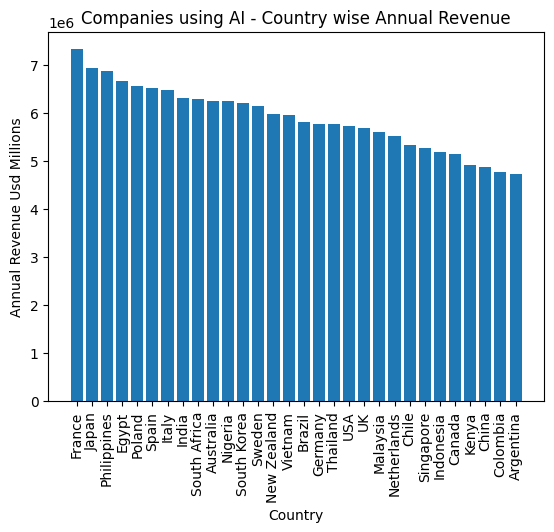

In [35]:
plt.bar(ann_rev.index, ann_rev.values)
plt.xlabel("Country")
plt.ylabel("Annual Revenue Usd Millions")
plt.title("Companies using AI - Country wise Annual Revenue")
plt.xticks(rotation=90)
plt.show()


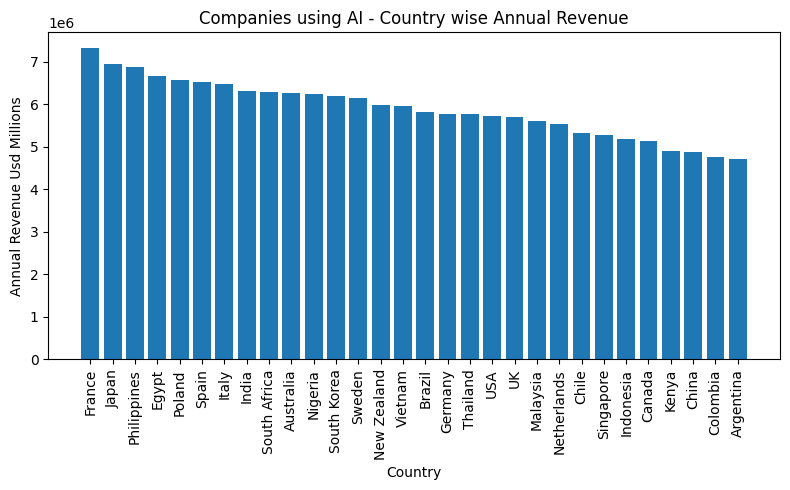

In [36]:
plt.figure(figsize=(8,5))
plt.bar(ann_rev.index, ann_rev.values)
plt.xlabel("Country")
plt.ylabel("Annual Revenue Usd Millions")
plt.title("Companies using AI - Country wise Annual Revenue")
plt.xticks(rotation=90, ha="center")
plt.tight_layout()
plt.show()



Let us find out how the trend changed over the years

In [37]:
yearly_avg = df.groupby("survey_year")["annual_revenue_usd_millions"].mean().round(2)
yearly_avg


survey_year
2023    1179.73
2024    1180.32
2025    1176.02
2026    1185.31
Name: annual_revenue_usd_millions, dtype: float64

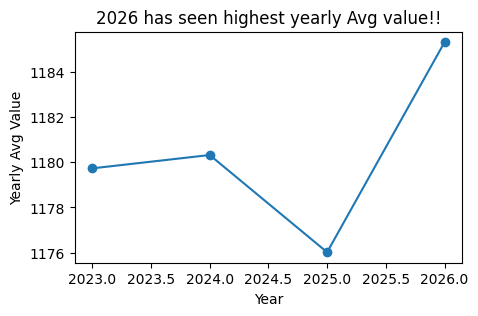

In [38]:
plt.figure(figsize=(5,3))
plt.plot(
    yearly_avg.index, 
    yearly_avg.values,
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Yearly Avg Value")
plt.title("2026 has seen highest yearly Avg value!!")
plt.show()


In [39]:
# Identify numerical vs categorical
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

C:\Users\HemantEliteBookAdmin\AppData\Local\Temp\ipykernel_22180\529066763.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [40]:
numeric_cols

Index(['response_id', 'survey_year', 'num_employees',
       'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
       'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'],
      dtype='str')

In [41]:
categorical_cols

Index(['company_id', 'quarter', 'country', 'region', 'industry',
       'company_size', 'company_age_group', 'ai_adoption_stage',
       'ai_primary_tool', 'ai_use_case', 'data_privacy_level',
       'ai_ethics_committee', 'survey_source', 'data_collection_method'],
      dtype='str')

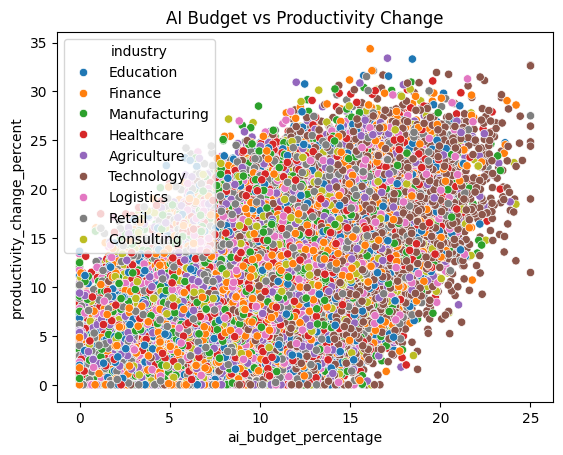

In [42]:
sns.scatterplot(
    data=df,
    x='ai_budget_percentage',
    y='productivity_change_percent',
    hue='industry'
)
plt.title("AI Budget vs Productivity Change")
plt.show()

This is showing mixed results
1. Companies investing more in AI often see better productivity gains.
2. AI spending alone does NOT guarantee results
3. Industry is not a strong differentiator here
4. Throwing more money at AI may not linearly improve productivity

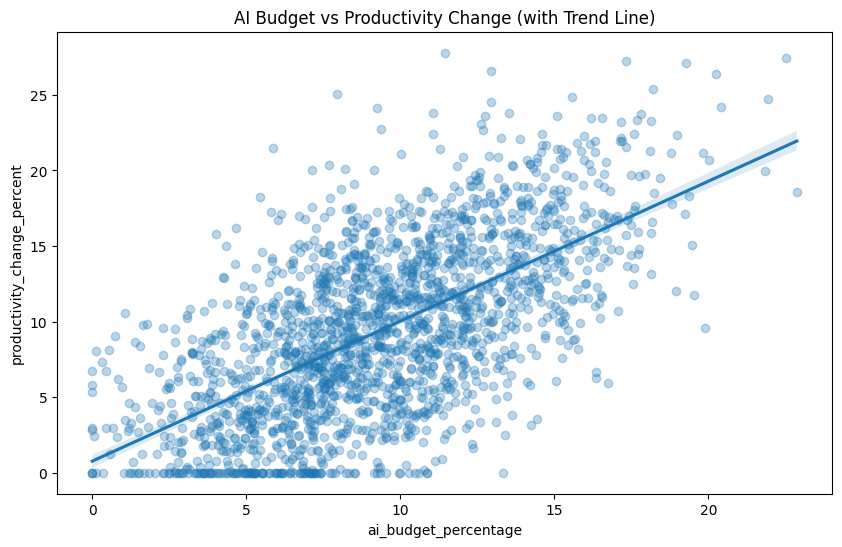

In [43]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df.sample(n=min(2000, len(df)), random_state=42),
    x='ai_budget_percentage',
    y='productivity_change_percent',
    scatter_kws={'alpha': 0.3}
)

plt.title("AI Budget vs Productivity Change (with Trend Line)")
plt.show()

Upward trend in this chart shows that - 
1. Genrally companies that spend more on AI generally see higher productivity gains . 
2. however, some comapnies invest in AI but get little to no return because of various reasons

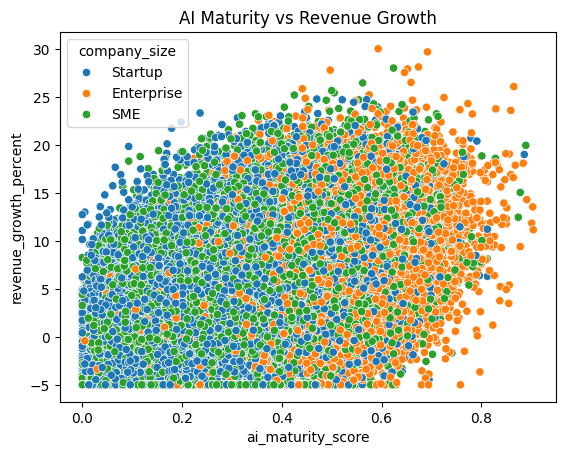

In [44]:
sns.scatterplot(
    data=df,
    x='ai_maturity_score',
    y='revenue_growth_percent',
    hue='company_size'
)
plt.title("AI Maturity vs Revenue Growth")
plt.show()

This chart shows
1. Companies that are more mature in AI (not just spending) tend to grow more.
2. Early-stage AI adoption is often inefficient or costly
3. Startups can win, but are less stable

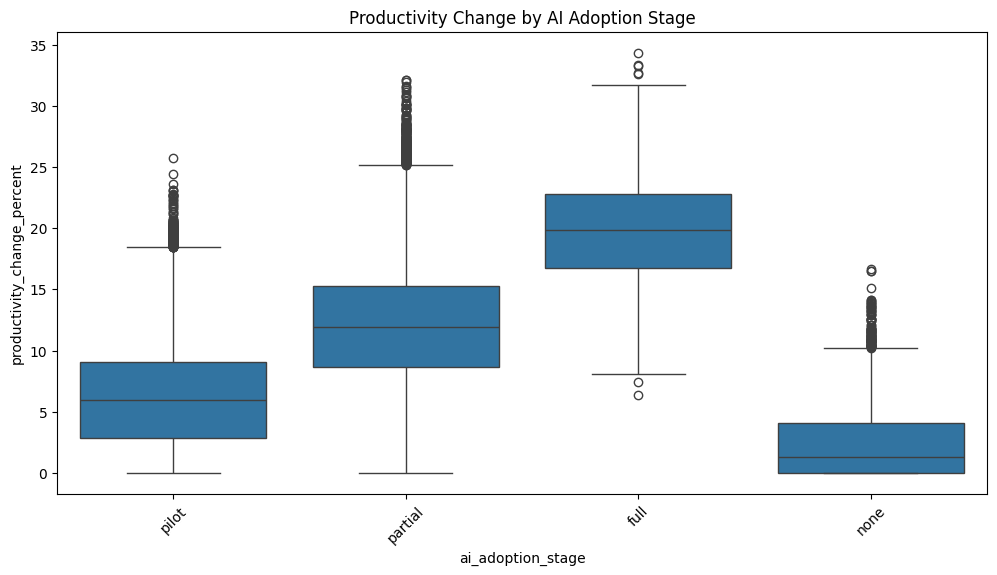

In [45]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='ai_adoption_stage',
    y='productivity_change_percent'
)
plt.xticks(rotation=45)
plt.title("Productivity Change by AI Adoption Stage")
plt.show()

This chart tells us
1. As companies move deeper into AI adoption, productivity consistently improves.
2. Full AI integration delivers the biggest productivity benefits
3. Not all companies succeed equally — execution still matters
4. None - tells AI is not only the driver - there are some other factors

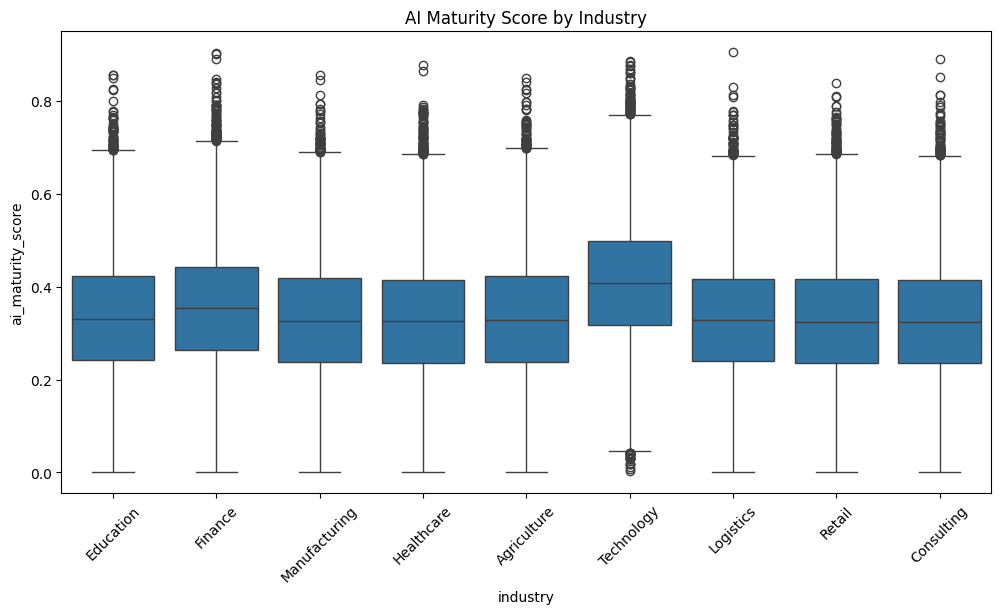

In [46]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='industry',
    y='ai_maturity_score'
)
plt.xticks(rotation=45)
plt.title("AI Maturity Score by Industry")
plt.show()

This chart tells us
1. AI maturity is evenly distributed across industries
2. Tech companies are a bit more advanced, but not dramatically
3. Finance is also relatively mature, likely due to heavy data usage
4. Most industries are at similar stages of AI evolution

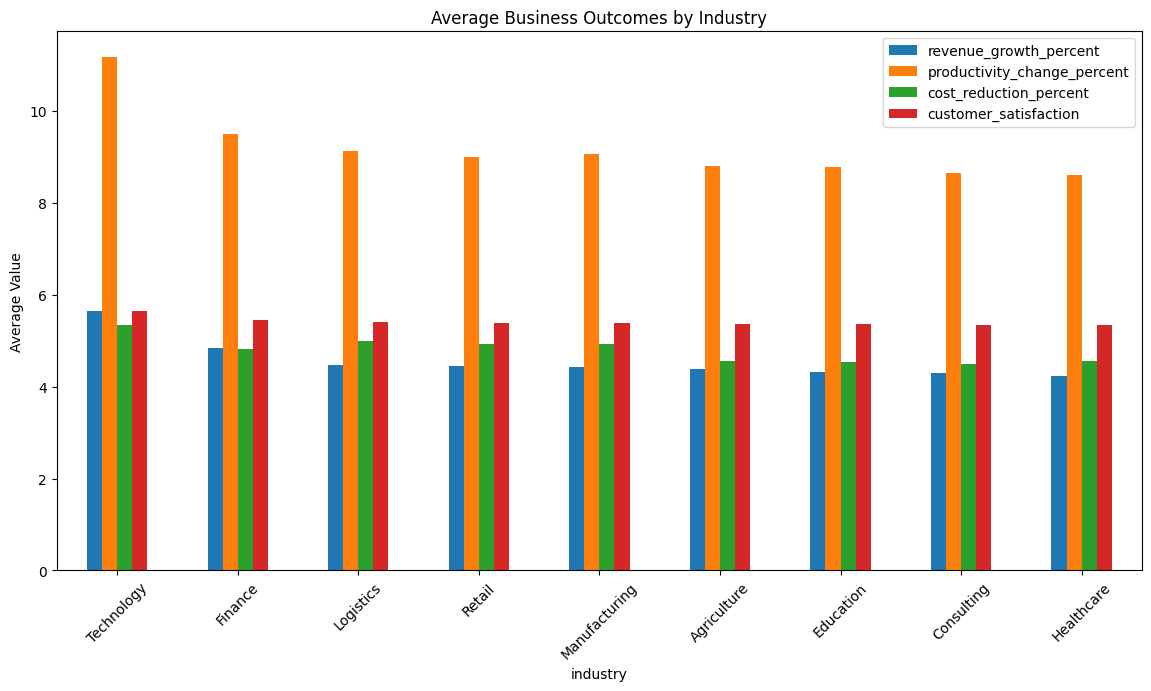

In [47]:
summary = df.groupby('industry')[
    ['revenue_growth_percent', 'productivity_change_percent',
     'cost_reduction_percent', 'customer_satisfaction']
].mean().sort_values('revenue_growth_percent', ascending=False)

summary.plot(kind='bar', figsize=(14, 7))
plt.title("Average Business Outcomes by Industry")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

This chart tells us that 
1. Tech companies are getting the most value from AI
2. Performance differences are incremental, not dramatic
3. AI is delivering value across all industries

In [48]:
df.nlargest(10, 'revenue_growth_percent')[[
    'industry', 'company_size', 'ai_maturity_score', 'revenue_growth_percent'
]]

,industry,company_size,ai_maturity_score,revenue_growth_percent
12862,Technology,Enterprise,0.593,30.00
93860,Technology,Enterprise,0.692,29.68
113283,Logistics,Enterprise,0.674,28.11
63536,Finance,SME,0.624,27.99
55925,Consulting,Enterprise,0.652,27.90
9122,Education,Enterprise,0.497,27.78
98360,Technology,Enterprise,0.646,27.53
29522,Manufacturing,Enterprise,0.659,26.50
58284,Technology,SME,0.562,26.44
47793,Healthcare,Enterprise,0.865,26.06


This tells us - Large companies are better at converting AI into revenue growth

In [49]:
df.nsmallest(10, 'revenue_growth_percent')[[
    'industry', 'company_size', 'ai_maturity_score', 'revenue_growth_percent'
]]

,industry,company_size,ai_maturity_score,revenue_growth_percent
37,Education,Enterprise,0.293,-5.0
57,Manufacturing,Startup,0.215,-5.0
62,Finance,SME,0.134,-5.0
71,Finance,SME,0.274,-5.0
105,Manufacturing,Startup,0.117,-5.0
137,Healthcare,Startup,0.034,-5.0
147,Healthcare,Startup,0.046,-5.0
156,Healthcare,Startup,0.235,-5.0
158,Healthcare,Startup,0.298,-5.0
173,Healthcare,Startup,0.049,-5.0


This tells us that - Smaller companies struggle more to turn AI into results

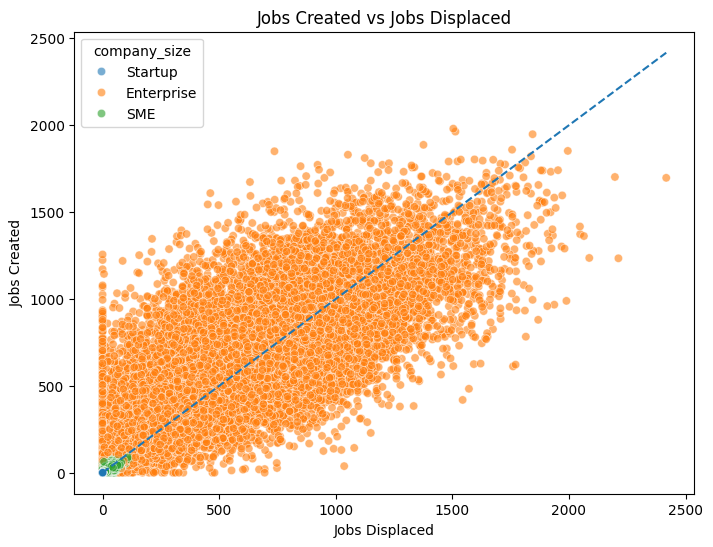

In [50]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='jobs_displaced',
    y='jobs_created',
    hue='company_size',
    alpha=0.6
)

plt.plot([0, df['jobs_displaced'].max()],
         [0, df['jobs_displaced'].max()],
         linestyle='--')  # reference line

plt.title("Jobs Created vs Jobs Displaced")
plt.xlabel("Jobs Displaced")
plt.ylabel("Jobs Created")
plt.show()

This tells us that - 
1. AI is creating more jobs than it eliminates
2. on the other hand Companies that automate more also expand more and maybe hire more for different roles - means the traditional jobs are getting lost

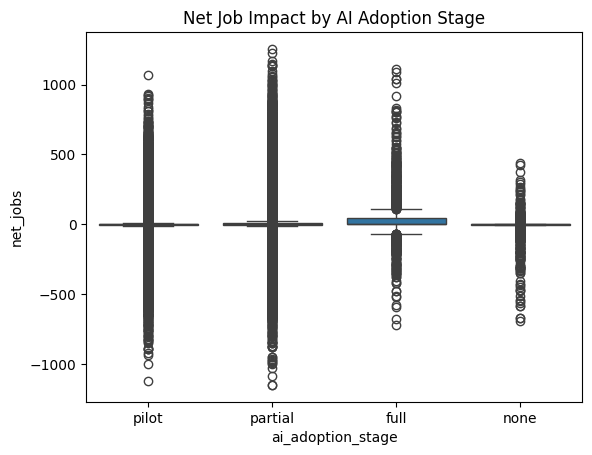

In [51]:
df['net_jobs'] = df['jobs_created'] - df['jobs_displaced']

sns.boxplot(
    data=df,
    x='ai_adoption_stage',
    y='net_jobs'
)

plt.title("Net Job Impact by AI Adoption Stage")
plt.show()

This tells AI does not immediately create jobs — it takes maturity

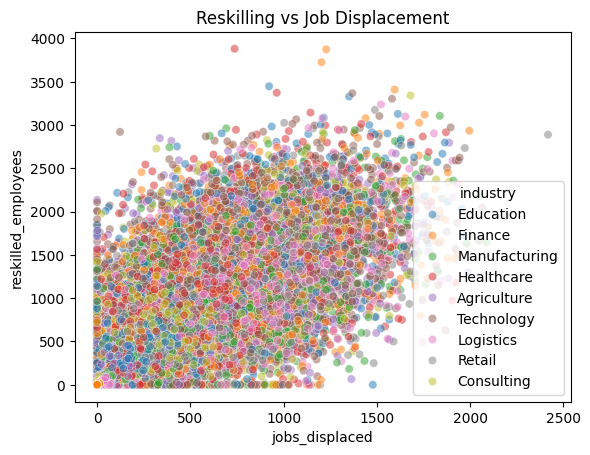

In [52]:
sns.scatterplot(
    data=df,
    x='jobs_displaced',
    y='reskilled_employees',
    hue='industry',
    alpha=0.5
)

plt.title("Reskilling vs Job Displacement")
plt.show()

THis chart tells 
1. Companies automate more and invest more on reskilling
2. Some companies tend to reskill and others displace without reskilling

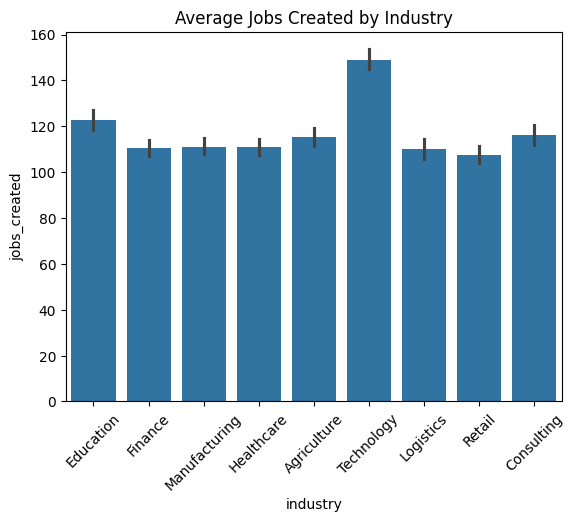

In [53]:
sns.barplot(
    data=df,
    x='industry',
    y='jobs_created'
)

plt.xticks(rotation=45)
plt.title("Average Jobs Created by Industry")
plt.show()

Technology as created more jobs

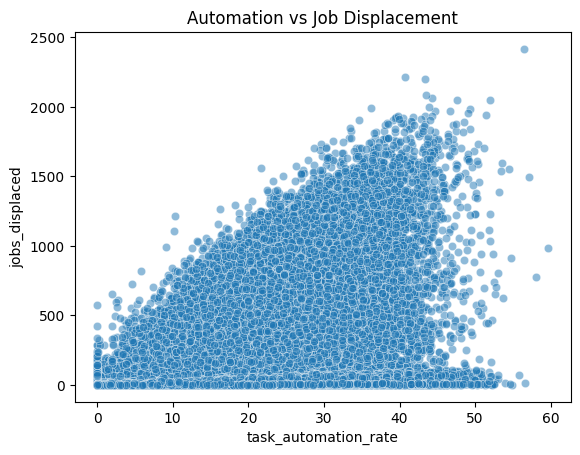

In [54]:
sns.scatterplot(
    data=df,
    x='task_automation_rate',
    y='jobs_displaced',
    alpha=0.5
)

plt.title("Automation vs Job Displacement")
plt.show()

OMG this is telling that high automation leads to jobs displacement!!!

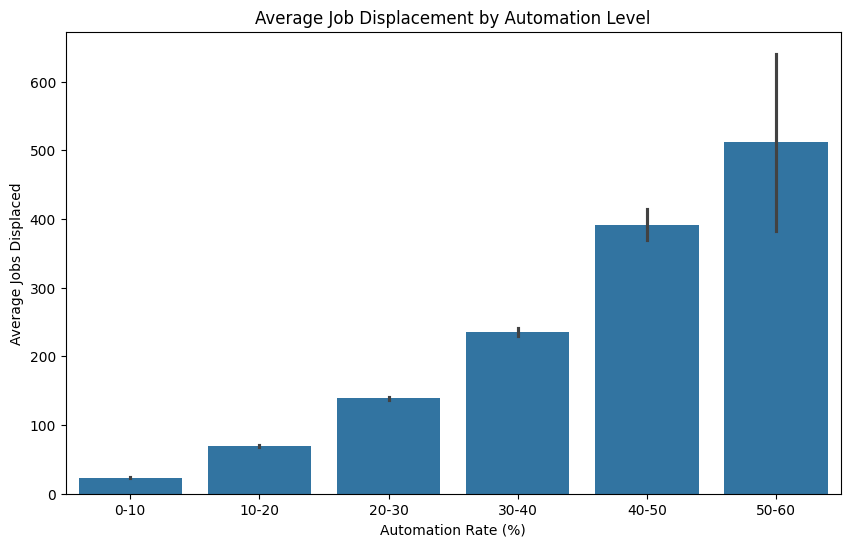

In [55]:
df['automation_bin'] = pd.cut(
    df['task_automation_rate'],
    bins=[0, 10, 20, 30, 40, 50, 60],
    labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60']
)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='automation_bin',
    y='jobs_displaced'
)

plt.title("Average Job Displacement by Automation Level")
plt.xlabel("Automation Rate (%)")
plt.ylabel("Average Jobs Displaced")
plt.show()

More automation leads to consistently more job displacement

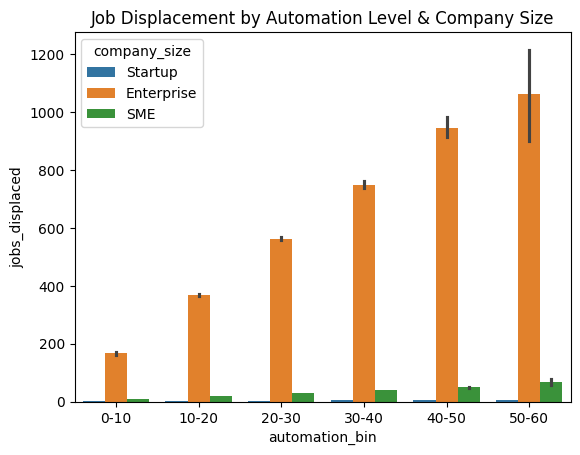

In [56]:
sns.barplot(
    data=df,
    x='automation_bin',
    y='jobs_displaced',
    hue='company_size'
)

plt.title("Job Displacement by Automation Level & Company Size")
plt.show()

Large companies - automate more aggressively & displace far more jobs
Startups & SMEs- minimal displacement

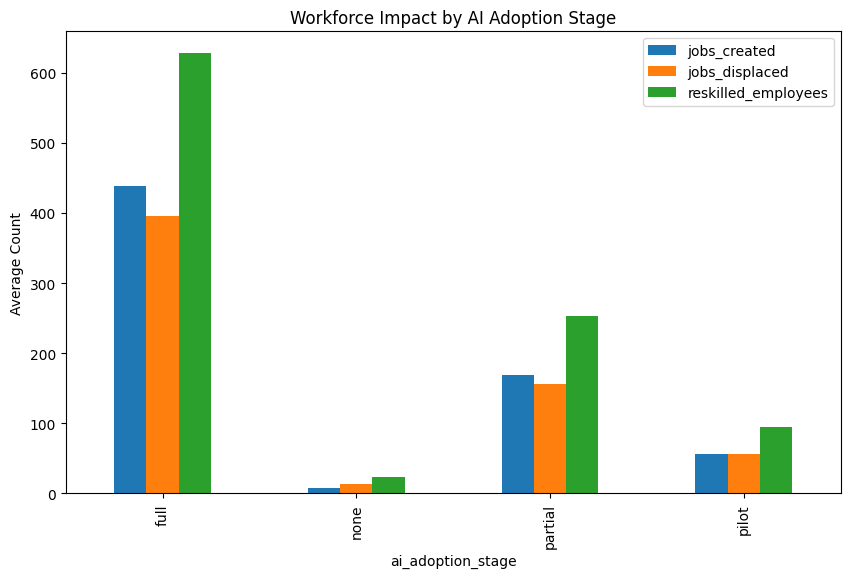

In [57]:
summary = df.groupby('ai_adoption_stage')[[
    'jobs_created',
    'jobs_displaced',
    'reskilled_employees'
]].mean()

summary.plot(kind='bar', figsize=(10, 6))

plt.title("Workforce Impact by AI Adoption Stage")
plt.ylabel("Average Count")
plt.show()

This is telling a fantastic story
1. Full adoption - high jobs displacement but higher jobs creation and reskilling
2. AI is not reducing jobs overall 
3. Companies are transforming their workforce 

I have second dataset - Country Wise Technology Data
This dataset gives country wise some key information

In [58]:
dfc = pd.read_csv("../data/country_ai_index.csv")


Visually checking the data

In [59]:
dfc

,country,region,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,USA,North America,72596.06,92.10,87.14,Moderate,19952,417.69
1,Canada,North America,55834.08,96.78,84.67,Moderate,4233,393.62
2,Germany,Europe,54777.23,91.98,85.01,Strict,6475,369.58
3,UK,Europe,52827.64,91.41,83.85,Moderate,5612,345.98
4,France,Europe,47719.02,92.23,83.46,Moderate,4722,353.71
5,Netherlands,Europe,57719.04,93.17,91.44,Strict,2858,419.02
6,Sweden,Europe,62895.06,96.31,89.87,Strict,2648,459.49
7,Spain,Europe,42920.92,87.06,79.81,Moderate,2266,289.09
8,Italy,Europe,39436.63,86.01,75.65,Moderate,2234,296.83
9,Poland,Europe,26651.07,88.30,70.84,Moderate,1823,233.18


Checking first 5 rows

In [60]:
dfc.head()

,country,region,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,USA,North America,72596.06,92.10,87.14,Moderate,19952,417.69
1,Canada,North America,55834.08,96.78,84.67,Moderate,4233,393.62
2,Germany,Europe,54777.23,91.98,85.01,Strict,6475,369.58
3,UK,Europe,52827.64,91.41,83.85,Moderate,5612,345.98
4,France,Europe,47719.02,92.23,83.46,Moderate,4722,353.71


Checking the last 5 rows

In [61]:
dfc.tail()


,country,region,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
25,Nigeria,Africa,6133.11,56.40,59.10,Lenient,240,55.23
26,Kenya,Africa,5618.81,63.74,63.65,Lenient,191,82.73
27,Egypt,Africa,8450.84,71.54,64.59,Moderate,272,110.69
28,Australia,Oceania,64279.23,94.50,88.05,Moderate,3270,390.71
29,New Zealand,Oceania,54649.97,94.46,87.92,Moderate,1801,382.22


Checking the shape

In [62]:
dfc.shape

(30, 8)

Checking mathematical analysis on all the fields

In [63]:
dfc.describe()


,gdp_per_capita,internet_penetration,digital_maturity_index,ai_patent_filings_2024,ai_researchers_per_million
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,32440.890667,83.219333,77.157000,3441.233333,255.292667
std,22661.367334,11.539216,9.982764,4551.596550,138.619315
min,5618.810000,56.400000,59.100000,191.000000,55.230000
25%,12328.005000,75.582500,69.715000,981.250000,124.970000
50%,23866.050000,86.495000,76.155000,2020.500000,261.135000
75%,54194.387500,92.197500,86.797500,3992.250000,379.060000
max,72930.100000,96.780000,92.820000,19952.000000,501.200000


Checking fields with null values

In [64]:
dfc.isnull().sum()

country                       0
region                        0
gdp_per_capita                0
internet_penetration          0
digital_maturity_index        0
country_ai_policy             0
ai_patent_filings_2024        0
ai_researchers_per_million    0
dtype: int64

The data is pretty much clean and the is no need to identify records with null values

Checking duplicate records

In [65]:
print(dfc.loc[dfc.duplicated(keep=False)])


Empty DataFrame
Columns: [country, region, gdp_per_capita, internet_penetration, digital_maturity_index, country_ai_policy, ai_patent_filings_2024, ai_researchers_per_million]
Index: []


There is no duplicate record in this dataset

In [66]:
df.dtypes


response_id                       int64
company_id                          str
survey_year                       int64
quarter                             str
country                             str
region                              str
industry                            str
company_size                        str
num_employees                     int64
annual_revenue_usd_millions     float64
company_founding_year             int64
company_age                       int64
company_age_group                   str
ai_adoption_rate                float64
ai_adoption_stage                   str
years_using_ai                    int64
ai_primary_tool                     str
num_ai_tools_used                 int64
ai_use_case                         str
ai_projects_active                int64
ai_training_hours               float64
ai_budget_percentage            float64
ai_maturity_score               float64
ai_failure_rate                 float64
ai_investment_per_employee      float64


In [67]:
dfc.dtypes

country                           str
region                            str
gdp_per_capita                float64
internet_penetration          float64
digital_maturity_index        float64
country_ai_policy                 str
ai_patent_filings_2024          int64
ai_researchers_per_million    float64
dtype: object

Now I want to check if all the country codes in df exists in dfc

In [68]:
missing_countries = set(df['country']) - set(dfc['country'])
print(missing_countries)

set()


The missing_countries is empty, that means all the countries exist in dfc

In [69]:
dfc.describe()

,gdp_per_capita,internet_penetration,digital_maturity_index,ai_patent_filings_2024,ai_researchers_per_million
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,32440.890667,83.219333,77.157000,3441.233333,255.292667
std,22661.367334,11.539216,9.982764,4551.596550,138.619315
min,5618.810000,56.400000,59.100000,191.000000,55.230000
25%,12328.005000,75.582500,69.715000,981.250000,124.970000
50%,23866.050000,86.495000,76.155000,2020.500000,261.135000
75%,54194.387500,92.197500,86.797500,3992.250000,379.060000
max,72930.100000,96.780000,92.820000,19952.000000,501.200000


Converting csv files into SQLITE database 

In [70]:
connection = sqlite3.connect("..\data\AI_Adoption.db")
# Explicitly closing the connection because the database was getting locked.
connection.close()
# Reopening the database
connection = sqlite3.connect("..\data\AI_Adoption.db")
connection

Creating a function to get name of the csv files from data folder and convert them into a database file 

In [71]:
def createdb(data_folder):
    # Repeat for all files in the data folder and use a loop.
    folder = Path(data_folder)

    for file in folder.glob("*.csv"):
        if file.is_file():
            csvfile = pd.read_csv(f"{data_folder}/{file.name}")
            # Explicitly dropping the table before loading
            table_name = file.stem
            connection.execute(f"DROP TABLE IF EXISTS {table_name}")
            # Loading the csv file
            csvfile.to_sql(f"{table_name}", connection, if_exists="replace", index=False, chunksize=20,)

Passing the data folder name and calling the function createdb 

In [72]:
# passing the folder name to the function
data_folder = "../data"
createdb(data_folder)

Checking names of the tables in the sqlite database

In [73]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", connection)

,name
0,ai_company_adoption
1,country_ai_index


Creating a simple function to check records in a table by passing table name

In [74]:
def simple_sql(table_name):
    result = pd.read_sql(f"SELECT * from {table_name}", connection)
    return result

Checking contents from both the tables one by one
1. Checking contents of the table ai_company_adoption by calling the function simple_sql


In [75]:

table_name = "ai_company_adoption"
result1 = simple_sql(table_name)
result1

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149999,159996,COMP-10000,2025,Q4,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,19.01,1292,1027,1766,9.44,9.52,62,5.68,McKinsey Report,Phone Interview
150000,159997,COMP-10000,2026,Q1,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,15.56,466,883,803,10.65,6.94,56,5.57,Internal Corporate Survey,Research Compilation
150001,159998,COMP-10000,2026,Q2,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,13.38,1360,1474,1779,5.52,0.32,48,7.56,WEF Survey,API Scrape
150002,159999,COMP-10000,2026,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,12.75,1358,887,1648,11.87,7.85,69,6.00,WEF Survey,Research Compilation


2. Checking contents of the table country_ai_index by calling the function simple_sql

In [76]:
table_name = "country_ai_index"
result2 = simple_sql(table_name)
result2

,country,region,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,USA,North America,72596.06,92.10,87.14,Moderate,19952,417.69
1,Canada,North America,55834.08,96.78,84.67,Moderate,4233,393.62
2,Germany,Europe,54777.23,91.98,85.01,Strict,6475,369.58
3,UK,Europe,52827.64,91.41,83.85,Moderate,5612,345.98
4,France,Europe,47719.02,92.23,83.46,Moderate,4722,353.71
5,Netherlands,Europe,57719.04,93.17,91.44,Strict,2858,419.02
6,Sweden,Europe,62895.06,96.31,89.87,Strict,2648,459.49
7,Spain,Europe,42920.92,87.06,79.81,Moderate,2266,289.09
8,Italy,Europe,39436.63,86.01,75.65,Moderate,2234,296.83
9,Poland,Europe,26651.07,88.30,70.84,Moderate,1823,233.18


From my previous analysis I know in the table ai_company_adoption there are some records that has some fields with null values. The field names are "survey_source", "ai_adoption_stage", "region","company_size".

In [77]:
query1 = """ 
    select * from ai_company_adoption
    where
    survey_source IS NULL or ai_adoption_stage IS NULL or region IS NULL or company_size IS NULL
"""
pd.read_sql(query1, connection)

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,14,COMP-00001,2026,Q2,Italy,NaN,Education,NaN,57,48.31,...,11.81,2,3,4,4.31,9.75,52,5.22,LinkedIn Poll,Research Compilation
1,21,COMP-00002,2024,Q1,UK,Europe,Finance,Startup,18,14.66,...,7.84,0,1,2,5.43,6.11,55,3.65,NaN,Phone Interview
2,159980,COMP-09999,2025,Q4,Poland,Europe,Finance,Startup,16,4.56,...,3.93,1,0,0,9.06,7.96,46,3.87,McKinsey Report,Phone Interview


These results are exactly matching with my previous analysis

response_id	company_id	survey_year	quarter	country	region	industry	company_size	num_employees
14	COMP-00001	2026	Q2	Italy	NaN	Education	NaN	57
21	COMP-00002	2024	Q1	UK	Europe	Finance	Startup	18
159980	COMP-09999	2025	Q4	Poland	Europe	Finance	Startup	16	

and I can safely delete these 3 records

In [78]:
query1 = """ 
    delete from ai_company_adoption
    where
    survey_source IS NULL or ai_adoption_stage IS NULL or region IS NULL or company_size IS NULL
"""
connection.execute(query1)

Rechecking the database if the records are deleted or not

In [79]:
query1 = """ 
    select * from ai_company_adoption
    where
    survey_source IS NULL or ai_adoption_stage IS NULL or region IS NULL or company_size IS NULL
"""
pd.read_sql(query1, connection)

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method


From my previous analysis I know there are 2 duplicate records 
response_id  company_id  survey_year quarter  country  region  \
149997       159995  COMP-10000         2025      Q3  Nigeria  Africa   
149998       159995  COMP-10000         2025      Q3  Nigeria  Africa  

In [80]:
query2 = """ 
    select 
        response_id	,
        company_id	,
        survey_year	,
        quarter	,
        country	,
        region	,
        industry	,
        company_size	,
        num_employees	,
        annual_revenue_usd_millions	,
        company_founding_year	,
        company_age	,
        company_age_group	,
        ai_adoption_rate	,
        ai_adoption_stage	,
        years_using_ai	,
        ai_primary_tool	,
        num_ai_tools_used	,
        ai_use_case	,
        ai_projects_active	,
        ai_training_hours	,
        ai_budget_percentage	,
        ai_maturity_score	,
        ai_failure_rate	,
        ai_investment_per_employee	,
        regulatory_compliance_score	,
        data_privacy_level	,
        ai_ethics_committee	,
        ai_risk_management_score	,
        remote_work_percentage	,
        employee_satisfaction_score	,
        task_automation_rate	,
        time_saved_per_week	,
        productivity_change_percent	,
        jobs_displaced	,
        jobs_created	,
        reskilled_employees	,
        revenue_growth_percent	,
        cost_reduction_percent	,
        innovation_score	,
        customer_satisfaction	,
        survey_source	,
        data_collection_method	,
        count(*) as number_of_records
    from ai_company_adoption
    group by 
        response_id	,
        company_id	,
        survey_year	,
        quarter	,
        country	,
        region	,
        industry	,
        company_size	,
        num_employees	,
        annual_revenue_usd_millions	,
        company_founding_year	,
        company_age	,
        company_age_group	,
        ai_adoption_rate	,
        ai_adoption_stage	,
        years_using_ai	,
        ai_primary_tool	,
        num_ai_tools_used	,
        ai_use_case	,
        ai_projects_active	,
        ai_training_hours	,
        ai_budget_percentage	,
        ai_maturity_score	,
        ai_failure_rate	,
        ai_investment_per_employee	,
        regulatory_compliance_score	,
        data_privacy_level	,
        ai_ethics_committee	,
        ai_risk_management_score	,
        remote_work_percentage	,
        employee_satisfaction_score	,
        task_automation_rate	,
        time_saved_per_week	,
        productivity_change_percent	,
        jobs_displaced	,
        jobs_created	,
        reskilled_employees	,
        revenue_growth_percent	,
        cost_reduction_percent	,
        innovation_score	,
        customer_satisfaction	,
        survey_source	,
        data_collection_method	
    having count(*) > 1
"""
pd.read_sql(query2, connection)

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method,number_of_records
0,159995,COMP-10000,2025,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,700,1260,1387,5.95,7.89,57,6.1,WEF Survey,Phone Interview,2


This sql is showing the correct records those are duplicates

In [81]:
query2 = """ 
    select * from ai_company_adoption
    where
    company_id = 'COMP-10000' and survey_year = 2025 and quarter = 'Q3'
"""
pd.read_sql(query2, connection)


,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,159995,COMP-10000,2025,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,11.31,700,1260,1387,5.95,7.89,57,6.1,WEF Survey,Phone Interview
1,159995,COMP-10000,2025,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,11.31,700,1260,1387,5.95,7.89,57,6.1,WEF Survey,Phone Interview


Since both the records have identical values, I can find the rowid of the records and delete min(rowid)

In [82]:
query2 = """ 
    select rowid from ai_company_adoption
    where
    company_id = 'COMP-10000' and survey_year = 2025 and quarter = 'Q3'
"""
pd.read_sql(query2, connection)

,rowid
0,149998
1,149999


Deleting record where rowid = 149998 using function

In [83]:
def delete_records(file_rowid):
    query2 = f""" 
        delete from ai_company_adoption
        where
        rowid = {file_rowid}
    """
    connection.execute(query2)

Calling the function to delete the record

In [84]:
file_rowid = 149998
delete_records(file_rowid)


Checking if there are any duplicate records exists

In [85]:
query2 = """ 
    select * from ai_company_adoption
    where
    company_id = 'COMP-10000' and survey_year = 2025 and quarter = 'Q3'
"""
pd.read_sql(query2, connection)

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,159995,COMP-10000,2025,Q3,Nigeria,Africa,Healthcare,Enterprise,18038,2040.01,...,11.31,700,1260,1387,5.95,7.89,57,6.1,WEF Survey,Phone Interview


IN order to create basic visual, bulding sql that will give relationship between Total Annual Revenues of the companies and gdp of that country

In [86]:
query4 = """ 
    with 
        qry1 as (
            select country, sum(annual_revenue_usd_millions) as ann_rev 
                from 
                    ai_company_adoption
                group by 
                    country
            )
        select a.country, cast(a.gdp_per_capita as integer) as gdp, b.ann_rev
            from 
                country_ai_index a
            left join
                qry1 b
            on
                a.country = b.country
            order by 
                a.gdp_per_capita
""" 
df3 = pd.read_sql(query4, connection)

Building visuals to analyze relationship

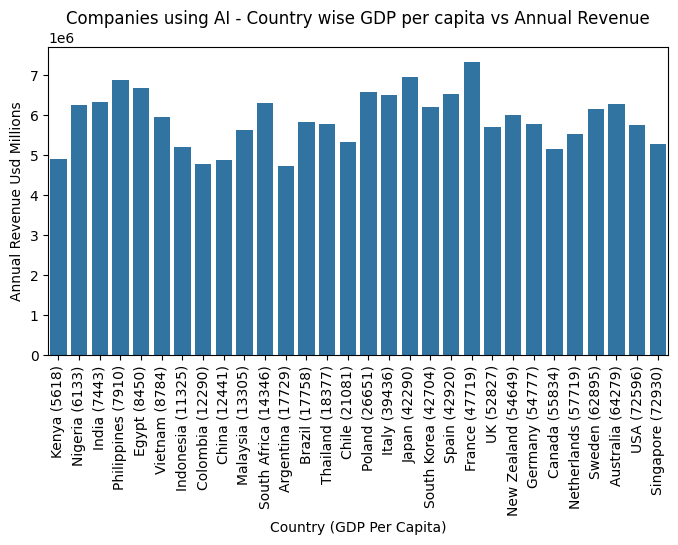

In [95]:
plt.figure(figsize=(8,4))

df3["country_gdp"] = (
    df3["country"] + 
    " (" + 
    df3["gdp"].astype(str) + 
    ")"
)

gdp_order = (df3.sort_values("gdp")["country_gdp"]
    .tolist())
# df3["gdp"].dropna().unique()
# gdp_order.sort()


sns.barplot(
    data=df3,
    x="country_gdp",
    y="ann_rev",
    order = gdp_order,
    errorbar=None
)

plt.xlabel("Country (GDP Per Capita)")
plt.ylabel("Annual Revenue Usd Millions")
plt.title("Companies using AI - Country wise GDP per capita vs Annual Revenue")
plt.xticks(rotation=90)
plt.show()


My conclusion is there is no direct relationship with the gdp per capita and total revenue of the companies using AI in that country.

Let us find out if there is any relationship with gdp per capita and ai_patent_filings_2024
Building sql statement

In [96]:
query5 = """ 
        select country, cast(gdp_per_capita as integer) as gdp, ai_patent_filings_2024
            from 
                country_ai_index
""" 
df5 = pd.read_sql(query5, connection)

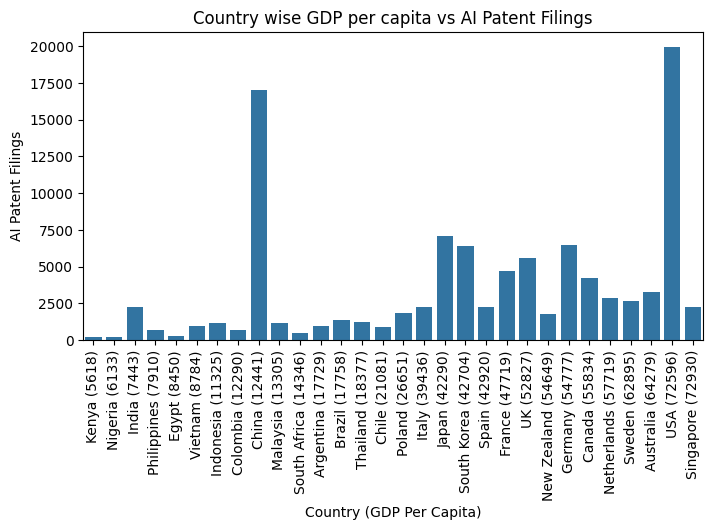

In [97]:
plt.figure(figsize=(8,4))

df5["country_gdp"] = (
    df5["country"] + 
    " (" + 
    df5["gdp"].astype(str) + 
    ")"
)

gdp_order = (df5.sort_values("gdp")["country_gdp"]
    .tolist())


sns.barplot(
    data=df5,
    x="country_gdp",
    y="ai_patent_filings_2024",
    order = gdp_order,
    errorbar=None
)

plt.xlabel("Country (GDP Per Capita)")
plt.ylabel("AI Patent Filings")
plt.title("Country wise GDP per capita vs AI Patent Filings")
plt.xticks(rotation=90)
plt.show()

In [ ]:
query3 = """ 
    select 
        a.country,
        a.task_automation_rate,
        a.jobs_displaced,
        round(c.gdp_per_capita,0) as gdp,
        c.internet_penetration
    from ai_company_adoption a
    join country_ai_index c
        on a.country = c.country
    order by c.gdp_per_capita
"""
df3 = pd.read_sql(query3, connection)


Designing graph

In [ ]:
plt.figure(figsize=(8,4))

df3["country_gdp"] = (
    df3["country"] + 
    " (" + 
    df3["gdp"].astype(str) + 
    ")"
)

gdp_order = (df3.sort_values("gdp")["country_gdp"]
    .tolist())
# df3["gdp"].dropna().unique()
# gdp_order.sort()


sns.barplot(
    data=df5,
    x="country_gdp",
    y="ann_rev",
    order = gdp_order,
    errorbar=None
)

plt.xlabel("Country (GDP Per Capita)")
plt.ylabel("Annual Revenue Usd Millions")
plt.title("Companies using AI - Country wise GDP per capita vs Annual Revenue")
plt.xticks(rotation=90)
plt.show()

In [ ]:
df3["automation_bin"] = pd.cut(
    df["task_automation_rate"],
    bins=[0,10,20,30,40,50,60],
    labels=["0-10","10-20","20-30","30-40","40-50","50-60"]
)

In [ ]:
df3["gdp_group"] = pd.qcut(
    df3["gdp"],
    q=3,
    labels=["Low GDP", "Medium GDP", "High GDP"]
)

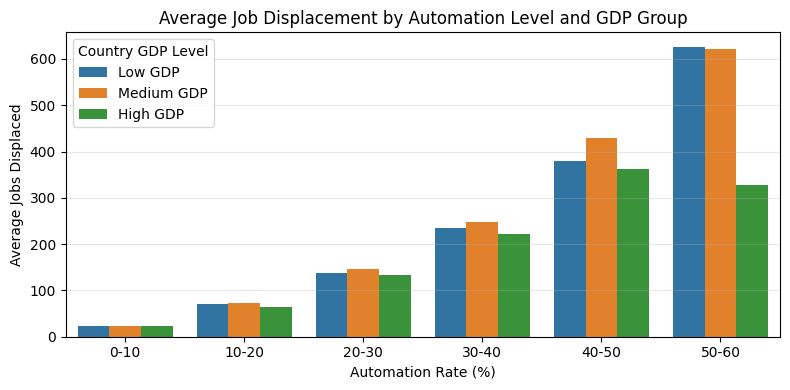

In [ ]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=df3,
    x="automation_bin",
    y="jobs_displaced",
    hue="gdp_group",
    errorbar=None
)

plt.title("Average Job Displacement by Automation Level and GDP Group")
plt.xlabel("Automation Rate (%)")
plt.ylabel("Average Jobs Displaced")

plt.legend(title="Country GDP Level")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

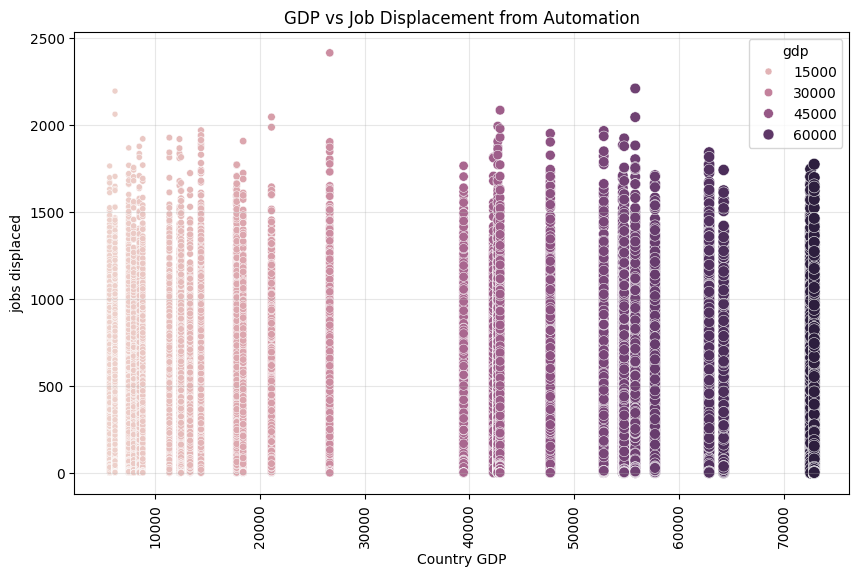

In [ ]:
plt.figure(figsize=(10,6))

# gdp_order = df3["internet_penetration"]

sns.scatterplot(
    data=df3,
    # x="gdp_per_capita",
    # y="task_automation_rate",
    # hue="task_automation_rate",
    # size="task_automation_rate",
    # alpha=0.5

    x="gdp",
    y="jobs_displaced",
    hue = "gdp",
    size = "gdp"
    # order =gdp_order,
    # errorbar=None

)

plt.title("GDP vs Job Displacement from Automation")
plt.xlabel("Country GDP")
plt.ylabel("jobs displaced")
plt.xticks(rotation=90)

plt.grid(alpha=0.3)

plt.show()